##  Data understanding

We are solving a **house price prediction** problem.

The question is:

> Given information about a house, can we predict its sale price?

This is a **supervised regression problem** because:

- The training data contains the correct answer: `SalePrice`.
- `SalePrice` is a continuous numeric value, not a category.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
train = pd.read_csv(r'C:\Users\divin\OneDrive\Desktop\Data_Science\project\UK_House_Price_Prediction_Model\train.csv')
test  = pd.read_csv(r'C:\Users\divin\OneDrive\Desktop\Data_Science\project\UK_House_Price_Prediction_Model\test.csv')
submission = pd.read_csv(r'C:\Users\divin\OneDrive\Desktop\Data_Science\project\UK_House_Price_Prediction_Model\sample_submission.csv')

In [42]:
print('Train Shape:', train.shape)
print('Test Shape:', test.shape)

print(train.head())

Train Shape: (1460, 81)
Test Shape: (1459, 80)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  S

##### SalePrice is the target variable it appears only in the training data because that is the value the model must learn to predict.

In [16]:
print('Columns in train but not test:', set(train.columns) - set(test.columns))


Columns in train but not test: {'SalePrice'}


#### Target Variable understading

- Minimum and maximum sale price.
- Mean and median.
- Whether the distribution is skewed.

In [27]:
target = 'SalePrice'
train[target].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

##### Mean > Median
It suggests that a small number of very expensive houses are pulling the average upward.

This is called right-skewness.

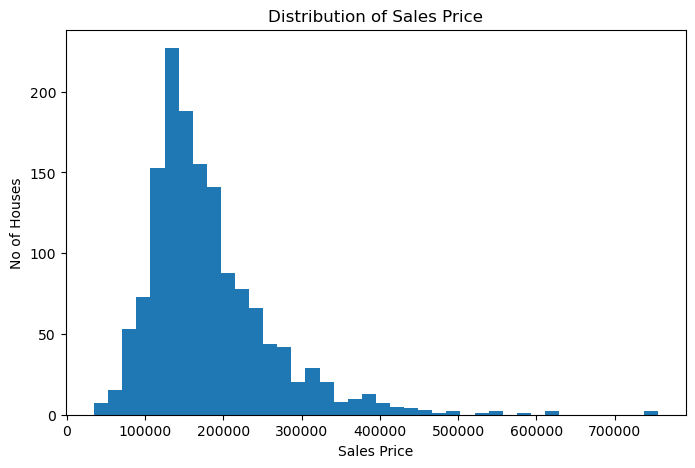

In [25]:
plt.figure(figsize=(8, 5))
plt.hist(train[target], bins=40)
plt.title('Distribution of Sales Price')
plt.xlabel('Sales Price')
plt.ylabel('No of Houses')
plt.show()

Since the SalePrice distribution is positively skewed, we apply a log1p transformation to reduce the influence of extremely expensive houses and create a distribution that is closer to normal, which is often beneficial for regression models.

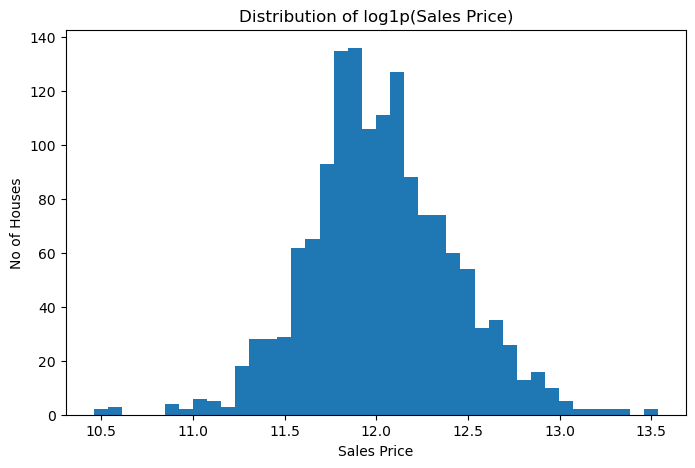

In [29]:
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(train[target]), bins=40)
plt.title('Distribution of log1p(Sales Price)')
plt.xlabel('Sales Price')
plt.ylabel('No of Houses')
plt.show()


In [30]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [31]:
train.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


#### Creating Feature Groups

In [35]:
feature_groups = {
    'ID': ['Id'],
    'Location and land': ['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2'],
    'Building type and style': ['BldgType', 'HouseStyle'],
    'Quality and condition': ['OverallQual', 'OverallCond', 'ExterQual', 'ExterCond', 'HeatingQC', 'KitchenQual', 'Functional'],
    'Construction and exterior': ['YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'Foundation'],
    'Basement': ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath'],
    'Utilities and rooms': ['Heating', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd'],
    'Fireplace and garage': ['Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond'],
    'Outdoor and extra features': ['PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC', 'Fence', 'MiscFeature', 'MiscVal'],
    'Sale information': ['MoSold', 'YrSold', 'SaleType', 'SaleCondition', 'SalePrice']
}
for group, cols in feature_groups.items():
    existing = [c for c in cols if c in train.columns]
    print(f'\n{group} ({len(existing)} columns)')
    print(existing)



ID (1 columns)
['Id']

Location and land (14 columns)
['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2']

Building type and style (2 columns)
['BldgType', 'HouseStyle']

Quality and condition (7 columns)
['OverallQual', 'OverallCond', 'ExterQual', 'ExterCond', 'HeatingQC', 'KitchenQual', 'Functional']

Construction and exterior (9 columns)
['YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'Foundation']

Basement (11 columns)
['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']

Utilities and rooms (12 columns)
['Heating', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd']

Fireplace and g

In [36]:
technical_types = pd.DataFrame({
    'column': train.columns,
    'pandas_dtype': train.dtypes.astype(str).values,
    'missing_count': train.isna().sum().values,
    'unique_values': train.nunique().values
})
display(technical_types.head(25))

,column,pandas_dtype,missing_count,unique_values
0,Id,int64,0,1460
1,MSSubClass,int64,0,15
2,MSZoning,object,0,5
3,LotFrontage,float64,259,110
4,LotArea,int64,0,1073
5,Street,object,0,2
6,Alley,object,1369,2
7,LotShape,object,0,4
8,LandContour,object,0,4
9,Utilities,object,0,2


In [37]:
feature_type_notes = pd.DataFrame([
    ['Id', 'Identifier', 'Drop before modelling; it is not a real house characteristic.'],
    ['SalePrice', 'Target', 'The value we want to predict.'],
    ['MSSubClass', 'Nominal categorical', 'Stored as number, but represents dwelling type categories.'],
    ['Neighborhood', 'Nominal categorical', 'Location category; use one-hot encoding.'],
    ['OverallQual', 'Ordinal numeric', 'Quality rating from 1 to 10; keep numeric.'],
    ['OverallCond', 'Ordinal numeric', 'Condition rating from 1 to 10; keep numeric.'],
    ['CentralAir', 'Binary categorical', 'Y/N; encode as categorical.'],
    ['LotArea', 'Continuous numeric', 'Land size in square feet.'],
    ['GrLivArea', 'Continuous numeric', 'Above-ground living area.'],
    ['YearBuilt', 'Date/year numeric', 'Useful, but also used to create HouseAge later.'],
    ['GarageCars', 'Discrete numeric', 'Garage capacity.'],
    ['GarageArea', 'Continuous numeric', 'Garage size in square feet.'],
    ['KitchenQual', 'Ordinal categorical', 'Excellent/Good/Typical/Fair/Poor; can be ordinal encoded or one-hot encoded.'],
    ['SaleType', 'Nominal categorical', 'Type of sale transaction.'],
    ['SaleCondition', 'Nominal categorical', 'Condition of sale transaction.']
], columns=['Column', 'ML feature type', 'How to treat it'])

display(feature_type_notes)

,Column,ML feature type,How to treat it
0,Id,Identifier,Drop before modelling; it is not a real house ...
1,SalePrice,Target,The value we want to predict.
2,MSSubClass,Nominal categorical,"Stored as number, but represents dwelling type..."
3,Neighborhood,Nominal categorical,Location category; use one-hot encoding.
4,OverallQual,Ordinal numeric,Quality rating from 1 to 10; keep numeric.
5,OverallCond,Ordinal numeric,Condition rating from 1 to 10; keep numeric.
6,CentralAir,Binary categorical,Y/N; encode as categorical.
7,LotArea,Continuous numeric,Land size in square feet.
8,GrLivArea,Continuous numeric,Above-ground living area.
9,YearBuilt,Date/year numeric,"Useful, but also used to create HouseAge later."


In [38]:
missing = train.isna().sum().sort_values(ascending=False)
missing_percent = (missing / len(train) * 100).round(2)
missing_table = pd.DataFrame({
    'missing_count': missing,
    'missing_percent': missing_percent
})
display(missing_table[missing_table['missing_count'] > 0])

,missing_count,missing_percent
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageYrBlt,81,5.55
GarageCond,81,5.55
GarageType,81,5.55


In [39]:
na_means_none = [
    'Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'PoolQC', 'Fence', 'MiscFeature'
]

real_missing_or_numeric = [
    'LotFrontage', 'MasVnrType', 'MasVnrArea', 'Electrical', 'GarageYrBlt'
]

print('Columns where NA usually means the feature is not present:')
print([c for c in na_means_none if c in train.columns])

print('\nColumns to inspect/impute carefully:')
print([c for c in real_missing_or_numeric if c in train.columns])

Columns where NA usually means the feature is not present:
['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']

Columns to inspect/impute carefully:
['LotFrontage', 'MasVnrType', 'MasVnrArea', 'Electrical', 'GarageYrBlt']


In [41]:
def basic_etl(df):
    df = df.copy()
    
    # MSSubClass is a dwelling category even though it is stored as a number.
    if 'MSSubClass' in df.columns:
        df['MSSubClass'] = df['MSSubClass'].astype(str)
    
    return df

train_basic = basic_etl(train)
test_basic = basic_etl(test)

train_basic.to_csv(
    'C:/Users/divin/OneDrive/Desktop/Data_Science/project/UK_House_Price_Prediction_Model/train_basic.csv',
    index=False
)

test_basic.to_csv(
    'C:/Users/divin/OneDrive/Desktop/Data_Science/project/UK_House_Price_Prediction_Model/test_basic.csv',
     index=False)

print('Saved:')

Saved:


This is a supervised regression problem.
SalePrice is the target variable.
The test file does not contain SalePrice.
Some numeric-looking columns are actually categorical, especially MSSubClass.
Many missing values mean “feature not present”, not “unknown”.
Feature engineering opportunities were identified but not applied yet.